# Assignment 1 - Anomaly Detection - Bank Fraud
You are given a dataset of bank transactions, some of which have been marked as fraud. It is up to you to train, validate and test an anomaly detection algorithm to automatically detect fraudulent transactions. By working through this notebook you can obtain up to 10 points, which will result in your final grade.

## Assignment submission
To submit this assignment, you will have to
- Submit a prediction for the `test` dataset to the https://security.eemcs.utwente.nl server.
- Upload the final version of your notebook (including the outputs) to Canvas.

### Server submission
On the https://security.eemcs.utwente.nl server, you will need to register an account if you haven't done so already. If you run into issues with registering an account, please contact the teacher of the course.

Navigate to `Challenges` -> `Cyber Data Analytics` -> `Assignment 1 - Anomaly Detection`. Here you can start the docker conainer that will spin up the server that is required to answer question 10 of this assignment.

## Libraries
You will need the following Python libraries for this assignment:
- [matplotlib](https://matplotlib.org/)
- [numpy](https://numpy.org)
- [pandas](https://pandas.pydata.org/)
- [scikit-learn](https://scikit-learn.org/stable/index.html)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

## Load the data
**Question 1. [0.5pts]** Load the train and test data from `data/train.csv` and `data/test.csv` into a pandas dataframe.

In [2]:
df_train = pd.read_csv('./data/train.csv')
df_test = pd.read_csv('./data/test.csv')

In [3]:
df_train.head()

,Id,issuercountrycode,txvariantcode,bin,amount,currencycode,shoppercountrycode,shopperinteraction,cardverificationcodesupplied,cvcresponsecode,accountcode,mail_id,ip_id,card_id,label
0,103901,AU,mccredit,517969.0,1000.0,AUD,AU,Ecommerce,True,0,APACAccount,email21099,ip31260,card182682,1
1,210427,GB,visadebit,465944.0,4815.0,GBP,GB,Ecommerce,True,1,UKAccount,email52090,ip314584,card151253,1
2,112529,GB,visadebit,454313.0,14495.0,GBP,GB,Ecommerce,True,1,UKAccount,email207206,ip51528,card47990,1
3,208878,AU,mccredit,516361.0,11000.0,AUD,AU,Ecommerce,True,0,APACAccount,email284873,ip114386,card95641,1
4,28936,GB,mccredit,542011.0,6090.0,GBP,GB,Ecommerce,True,1,UKAccount,email280026,ip324201,card74707,1


In [4]:
print(df_train['issuercountrycode'].value_counts())

issuercountrycode
GB    99769
AU    12542
SE    10213
MX     5634
NZ     2501
      ...  
MD        1
BY        1
MN        1
CW        1
AI        1
Name: count, Length: 103, dtype: int64


In [5]:
df_train.describe()

,Id,bin,amount,cvcresponsecode,label
count,132656.000000,132656.000000,1.326560e+05,132656.000000,132656.000000
mean,118573.440086,484943.121623,1.895154e+04,0.816390,0.998342
std,68525.212152,35808.696680,4.163792e+04,0.393176,0.057568
min,2.000000,400046.000000,5.000000e+01,0.000000,-1.000000
25%,59236.500000,464438.000000,4.000000e+03,1.000000,1.000000
50%,118601.500000,475130.000000,6.595000e+03,1.000000,1.000000
75%,178192.500000,517722.000000,1.180000e+04,1.000000,1.000000
max,237035.000000,559620.000000,1.955765e+06,5.000000,1.000000


## Data exploration
**Question 2. [1pt]** If you look carefully, some of the items in the dataset are missing or null. In these cases you can do two things:
1. Values can be replaced by dummy data. Here you have to take into account the difference between numerical and catagorical data. This also alters the dataset, making it potentially more difficult to train an algorithm.
2. Samples containing missing values can be removed from the data. This gives you less information to train on, moreover you can never remove samples from a test dataset as this would skew your results.

Choose and implement a way to deal with missing data in both the train and test dataset.

In [6]:
isnull = df_train.isnull().sum()
print(isnull)

Id                                 0
issuercountrycode                  2
txvariantcode                      0
bin                                0
amount                             0
currencycode                       0
shoppercountrycode               193
shopperinteraction                 0
cardverificationcodesupplied    7482
cvcresponsecode                    0
accountcode                        0
mail_id                            0
ip_id                              0
card_id                            0
label                              0
dtype: int64


In [7]:
df_train['cardverificationcodesupplied'] = df_train['cardverificationcodesupplied'].fillna(df_train['cardverificationcodesupplied'].mode()[0])
df_test['cardverificationcodesupplied'] = df_test['cardverificationcodesupplied'].fillna(df_test['cardverificationcodesupplied'].mode()[0])

df_train['issuercountrycode'] = df_train['issuercountrycode'].fillna('Other')
df_train['shoppercountrycode'] = df_train['shoppercountrycode'].fillna('Other')
df_test['issuercountrycode'] = df_test['issuercountrycode'].fillna('Other')
df_test['shoppercountrycode'] = df_test['shoppercountrycode'].fillna('Other')

C:\Users\tim_a\AppData\Local\Temp\ipykernel_5936\2662750174.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train['cardverificationcodesupplied'] = df_train['cardverificationcodesupplied'].fillna(df_train['cardverificationcodesupplied'].mode()[0])
C:\Users\tim_a\AppData\Local\Temp\ipykernel_5936\2662750174.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_test['cardverificationcodesupplied'] = df_test['cardverificationcodesupplied'].fillna(df_test['cardverificationcodesupplied'].mode()[0])


In [8]:
df_train = df_train.dropna()

In [9]:
isnull = df_test.isnull().sum()
print(isnull)

Id                              0
issuercountrycode               0
txvariantcode                   0
bin                             0
amount                          0
currencycode                    0
shoppercountrycode              0
shopperinteraction              0
cardverificationcodesupplied    0
cvcresponsecode                 0
accountcode                     0
mail_id                         0
ip_id                           0
card_id                         0
dtype: int64


In [10]:
isnull = df_train.isnull().sum()
print(isnull)

Id                              0
issuercountrycode               0
txvariantcode                   0
bin                             0
amount                          0
currencycode                    0
shoppercountrycode              0
shopperinteraction              0
cardverificationcodesupplied    0
cvcresponsecode                 0
accountcode                     0
mail_id                         0
ip_id                           0
card_id                         0
label                           0
dtype: int64


Explore the features (columns) and values of the provided data to get a feeling for the data. Identify which features are numerical, and which are catagorical. 

**Question 3. [1pt]** Create a histogram for one numerical feature and a bar plot for one catagorical feature for the training set to compare the difference between normal and anomalous traffic. You can use these plots to visualise which features may be needed to perform anomaly detection.

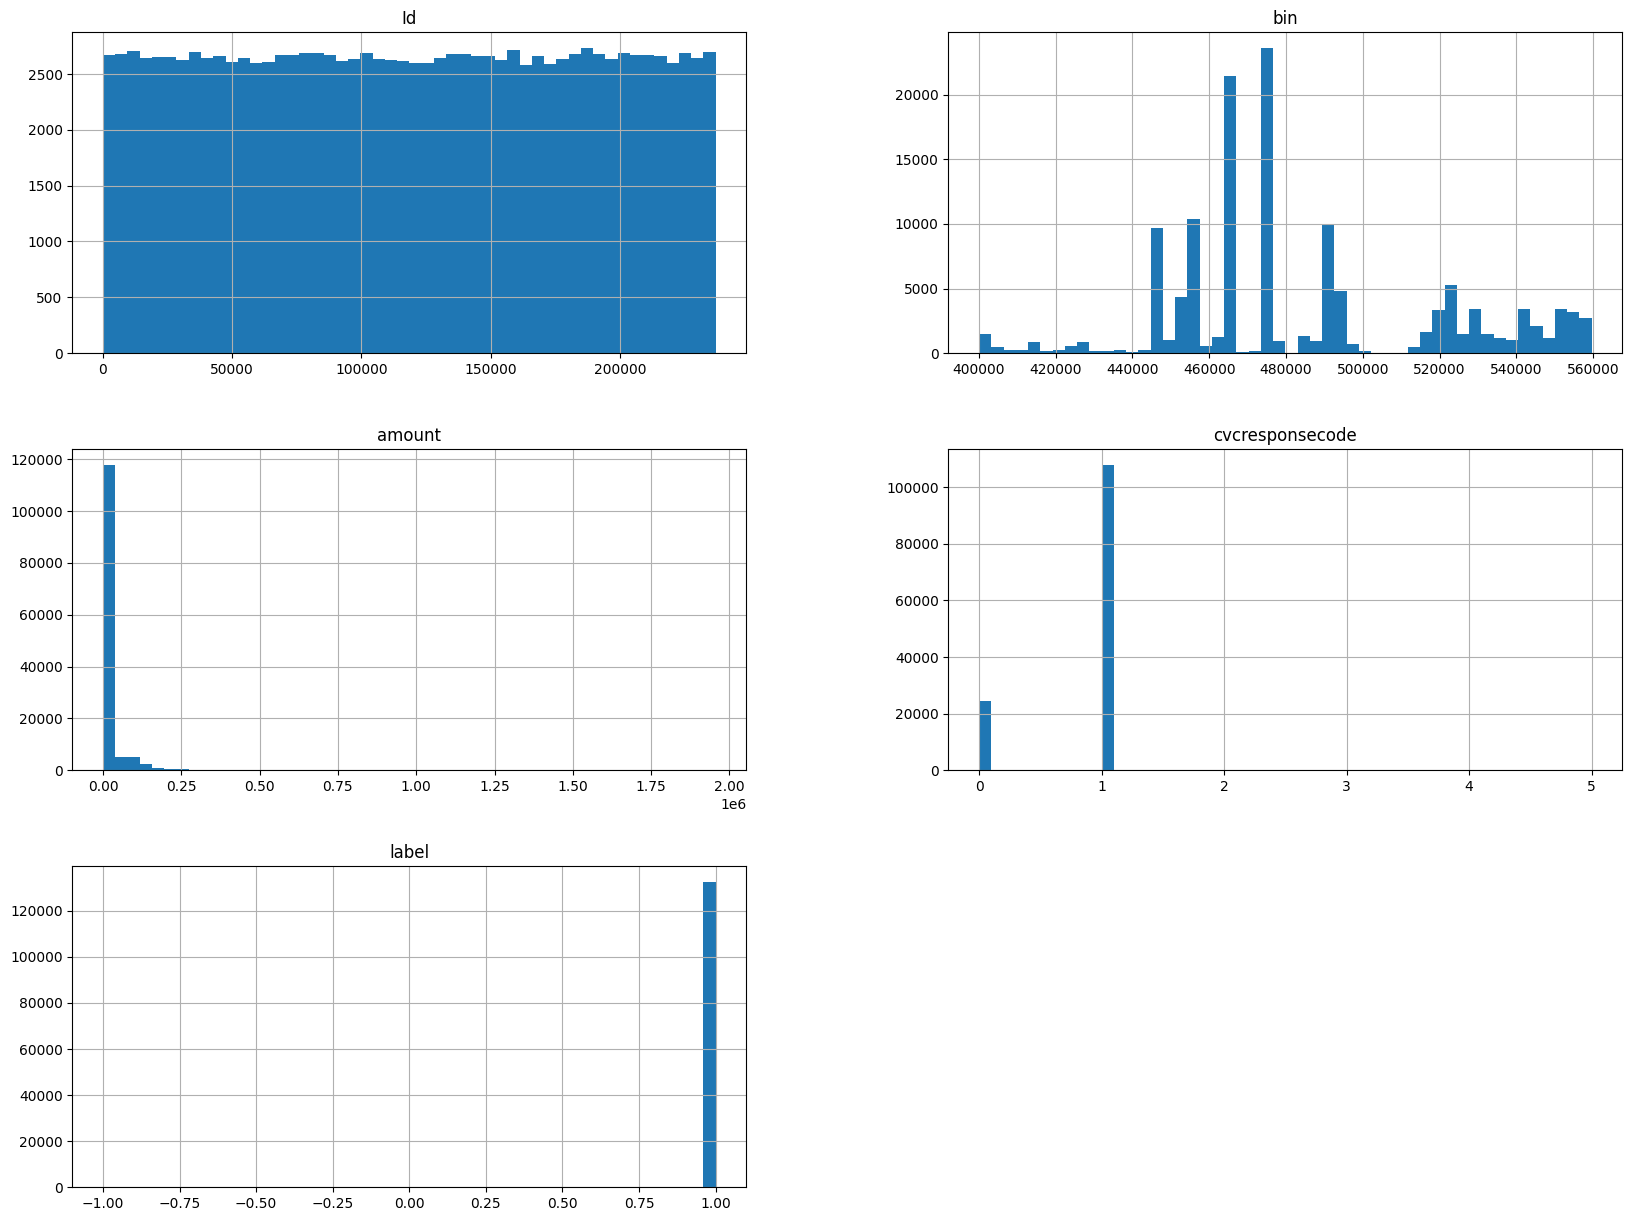

In [11]:
df_train.hist(bins=50, figsize=(20,15))
plt.show()

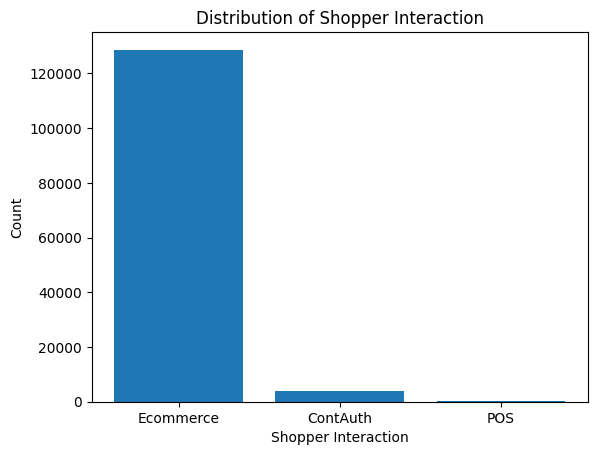

In [12]:
plt.bar(df_train['shopperinteraction'].value_counts().index, df_train['shopperinteraction'].value_counts().values)
plt.xlabel('Shopper Interaction')
plt.ylabel('Count')
plt.title('Distribution of Shopper Interaction')
plt.show()

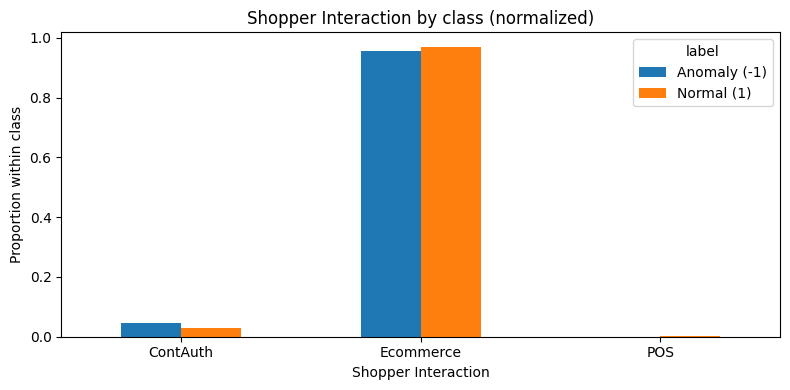

In [13]:
# Normalized within each class, so anomalies are visible despite class imbalance
ct = pd.crosstab(df_train['shopperinteraction'], df_train['label'], normalize='columns')
ct.columns = ['Anomaly (-1)' if c == -1 else 'Normal (1)' for c in ct.columns]
ct.plot(kind='bar', figsize=(8, 4))
plt.xlabel('Shopper Interaction')
plt.ylabel('Proportion within class')
plt.title('Shopper Interaction by class (normalized)')
plt.xticks(rotation=0)
plt.legend(title='label')
plt.tight_layout()
plt.show()

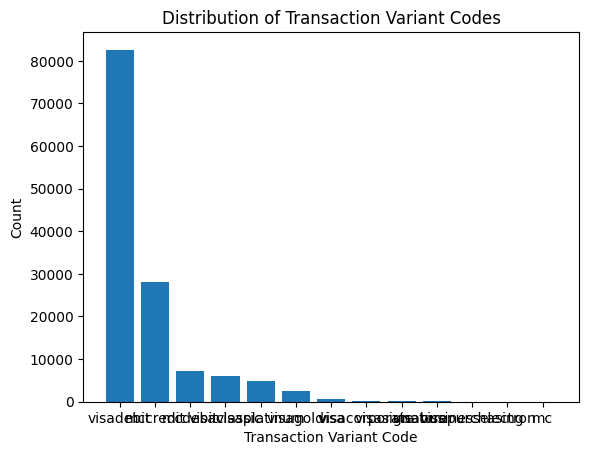

In [14]:
plt.bar(df_train['txvariantcode'].value_counts().index, df_train['txvariantcode'].value_counts().values)
plt.xlabel('Transaction Variant Code')
plt.ylabel('Count')
plt.title('Distribution of Transaction Variant Codes')
plt.show()

## Feature selection
Look at the features in the dataset, which features do you think are useful? Which features will definitely not be useful? Which features are you not sure of? 

At the very least, we cannot use the `label` as a feature, as this would immediately reveal which samples are anomalous. Moreover, this feature is missing in the `test` dataset, meaning that we could not use it in the first place. Therefore, we will split the data (often refered to in code as `X`) and label (often refered to in code as `y`).

**Question 4a. [0.5pts]** Split the datasets into the training data (`X_train`), training label (`y_train`) and test data (`X_test`).

**Question 4b. [0pts]** Next, remove the features in both the train and test data for which you are sure they will not be useful. Keep all other features. If you think all features are important, you can skip this part. Make sure you keep at least 1 catagorical feature for the next question.

In [15]:
ip_frequency = df_train.groupby(['card_id', 'ip_id'])['Id'].count()
ip_frequency

card_id     ip_id   
card100001  ip118859    1
card100002  ip276245    1
card100010  ip311056    1
card100012  ip200227    1
card100014  ip259892    1
                       ..
card99988   ip330829    1
card99989   ip13799     1
card99991   ip314134    1
card99993   ip298633    1
card99994   ip145570    1
Name: Id, Length: 128671, dtype: int64

In [16]:
mail_frequency = df_train.groupby(['card_id', 'mail_id'])['Id'].count()
mail_frequency

card_id     mail_id    
card100001  email93952     1
card100002  email257278    1
card100010  email239034    1
card100012  email77428     1
card100014  email118905    1
                          ..
card99988   email106712    1
card99989   email190042    1
card99991   email157366    1
card99993   email335832    1
card99994   email118604    1
Name: Id, Length: 124281, dtype: int64

In [17]:
df_train['IP_frequency'] = df_train.apply(lambda row: ip_frequency.get((row['card_id'], row['ip_id']), 0), axis=1)
df_train['mail_frequency'] = df_train.apply(lambda row: mail_frequency.get((row['card_id'], row['mail_id']), 0), axis=1)

In [18]:
df_train['card_count'] = df_train.groupby('card_id')['Id'].transform('count')
df_train['ip_count']   = df_train.groupby('ip_id')['Id'].transform('count')
df_train['mail_count'] = df_train.groupby('mail_id')['Id'].transform('count')

df_test['card_count'] = df_test.groupby('card_id')['Id'].transform('count')
df_test['ip_count']   = df_test.groupby('ip_id')['Id'].transform('count')
df_test['mail_count'] = df_test.groupby('mail_id')['Id'].transform('count')

In [19]:
df_train.drop(['Id', 'ip_id', 'mail_id', 'card_id'], axis=1, inplace=True)

In [20]:
X_anomalous = df_train[df_train['label'] == -1]
Y_anomalous = X_anomalous.pop('label') 
X_train = df_train[df_train['label'] != -1]
y_train = X_train.pop('label')

In [21]:
df_test.head()

,Id,issuercountrycode,txvariantcode,bin,amount,currencycode,shoppercountrycode,shopperinteraction,cardverificationcodesupplied,cvcresponsecode,accountcode,mail_id,ip_id,card_id,card_count,ip_count,mail_count
0,1,GB,mccredit,546097,4500,GBP,GB,Ecommerce,True,1,UKAccount,email132571,ip123779,card250169,1,2,1
1,17,NZ,mccredit,549464,8500,GBP,GB,Ecommerce,True,1,UKAccount,email132699,ip154616,card41507,1,1,1
2,23,GB,mccredit,552188,9150,GBP,GB,Ecommerce,True,1,UKAccount,email279149,ip257057,card118499,1,1,1
3,24,GB,visaclassic,454638,2275,GBP,GB,Ecommerce,True,1,UKAccount,email35130,ip318853,card161794,2,1,2
4,25,GB,visadebit,475714,6090,GBP,GB,Ecommerce,True,1,UKAccount,email301381,ip275986,card116209,1,1,1


In [22]:
ip_frequency = df_test.groupby(['card_id', 'ip_id'])['Id'].count()
mail_frequency = df_test.groupby(['card_id', 'mail_id'])['Id'].count()
df_test['IP_frequency'] = df_test.apply(lambda row: ip_frequency.get((row['card_id'], row['ip_id']), 0), axis=1)
df_test['mail_frequency'] = df_test.apply(lambda row: mail_frequency.get((row['card_id'], row['mail_id']), 0), axis=1)
df_test.drop(['Id', 'ip_id', 'mail_id', 'card_id'], axis=1, inplace=True)
X_test = df_test

## One-hot encoding
**Question 5a. [1pt]** One-hot encode the remaining catagorical features and replace the original values with their one-hot encoded counterparts.

We only one hot encode the top 1 countries and do the rest 'other'

In [23]:
top_10_issuer = X_train['issuercountrycode'].value_counts().nlargest(20).index 
top_10_shopper = X_train['shoppercountrycode'].value_counts().nlargest(20).index 

X_train['issuercountrycode'] = X_train['issuercountrycode'].apply(lambda x: x if x in top_10_issuer else 'Other')
X_train['shoppercountrycode'] = X_train['shoppercountrycode'].apply(lambda x: x if x in top_10_shopper else 'Other')

X_anomalous['issuercountrycode'] = X_anomalous['issuercountrycode'].apply(lambda x: x if x in top_10_issuer else 'Other')
X_anomalous['shoppercountrycode'] = X_anomalous['shoppercountrycode'].apply(lambda x: x if x in top_10_shopper else 'Other')

C:\Users\tim_a\AppData\Local\Temp\ipykernel_5936\2886577852.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['issuercountrycode'] = X_train['issuercountrycode'].apply(lambda x: x if x in top_10_issuer else 'Other')
C:\Users\tim_a\AppData\Local\Temp\ipykernel_5936\2886577852.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['shoppercountrycode'] = X_train['shoppercountrycode'].apply(lambda x: x if x in top_10_shopper else 'Other')
C:\Users\tim_a\AppData\Local\Temp\ipykernel_5936\28865778

In [24]:
from sklearn.preprocessing import OneHotEncoder

cat_cols = ['shopperinteraction', 'txvariantcode', 'issuercountrycode', 'currencycode', 'shoppercountrycode','accountcode' ]
cat_encoder = OneHotEncoder(handle_unknown='ignore')

cat_train = cat_encoder.fit_transform(X_train[cat_cols]).toarray()
cat_test = cat_encoder.transform(X_test[cat_cols]).toarray()

one_hot_df_train = pd.DataFrame(cat_train, columns=cat_encoder.get_feature_names_out(cat_cols), index=X_train.index)
one_hot_df_test = pd.DataFrame(cat_test, columns=cat_encoder.get_feature_names_out(cat_cols), index=X_test.index)
one_hot_df_anomalous = pd.DataFrame(cat_encoder.transform(X_anomalous[cat_cols]).toarray(), columns=cat_encoder.get_feature_names_out(cat_cols), index=X_anomalous.index)

X_train = pd.concat([X_train.drop(cat_cols, axis=1), one_hot_df_train], axis=1)
X_test = pd.concat([X_test.drop(cat_cols, axis=1), one_hot_df_test], axis=1)
X_anomalous = pd.concat([X_anomalous.drop(cat_cols, axis=1), one_hot_df_anomalous], axis=1)

In [25]:
X_train.head()

,bin,amount,cardverificationcodesupplied,cvcresponsecode,IP_frequency,mail_frequency,card_count,ip_count,mail_count,shopperinteraction_ContAuth,...,shoppercountrycode_PT,shoppercountrycode_SA,shoppercountrycode_SE,shoppercountrycode_TH,shoppercountrycode_US,shoppercountrycode_VN,accountcode_APACAccount,accountcode_MexicoAccount,accountcode_SwedenAccount,accountcode_UKAccount
0,517969.0,1000.0,True,0,1,1,1,1,1,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,465944.0,4815.0,True,1,1,1,1,1,1,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,454313.0,14495.0,True,1,1,1,1,1,1,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,516361.0,11000.0,True,0,1,1,1,6,1,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,542011.0,6090.0,True,1,1,1,1,1,1,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [26]:
X_train.shape

(132546, 75)

**Question 5b. [0pts]** If you haven't done so already, transform your `X_train`, `y_train` and `X_test` data, including the one-hot-encoded values into numpy arrays where the rows represent the samples, and the columns represent the features.

In [27]:
X_train = np.array(X_train)
Y_train = np.array(y_train)
X_test = np.array(X_test)

## Feature scaling
Use the following function to plot the features before and after scaling (see next question). You can observe that scaling improves separation between values, making it easier to find anomalies.

**Note:** Because PCA is used to downscale features to two dimensions, some information will be lost. This means that in some cases, overlapping datapoints may still be distinguished in their original form.

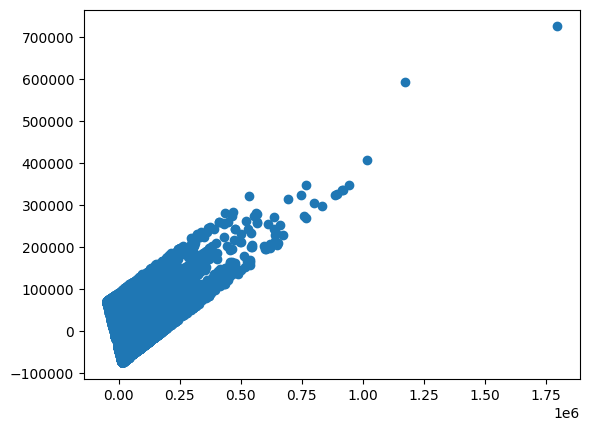

In [28]:
from sklearn.decomposition import PCA

def plot_pca(X, y):
    # Reduce features to two dimensions
    X = PCA(2).fit_transform(X)
    # Scatter features
    plt.scatter(X[:, 0][y ==  1], X[:, 1][y ==  1])
    plt.scatter(X[:, 0][y == -1], X[:, 1][y == -1])
    plt.show()

plot_pca(X_train, Y_train)

**Question 6. [1pt]** Scale the given features from 0-1 using Min-Max Scaling.

In [29]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_anomalous = scaler.transform(X_anomalous)
X_test = scaler.transform(X_test)

c:\Users\tim_a\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Use the `plot_pca()` function to plot the newly scaled features. Do the datapoints seem easier to separate?

**Note:** Because PCA is used to downscale features to two dimensions, some information will be lost. This means that in some cases, overlapping datapoints may still be distinguished in their original form.

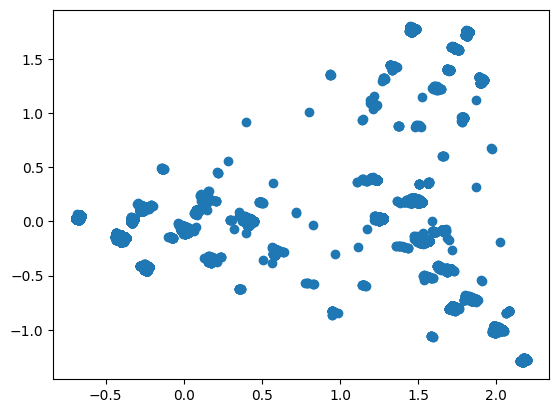

In [30]:
plot_pca(X_train, Y_train)

## Train-test-validate split
The data is already split into a train and test set. However, the test set does not contain any labels. Therefore, to measure the expected performance, we can subdivide the training set into a training (`X_train`, `y_train`) and validation set (`X_validate`, `y_validate`).

**Question 7. [1pt]** Split the training data into a train and validation set.

In [31]:
X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, test_size=0.3, random_state=42)
X_val = np.concatenate([X_val, np.array(X_anomalous)], axis=0)
Y_val = np.concatenate([Y_val, np.array(Y_anomalous)], axis=0)

## Anomaly detection
Now that we have preprocessed and split the dataset, we can train an anomaly detection algorithm.

**Question 8 [1pt].** Choose an anomaly detection algorithm, fit it with the training data and use it to predict the validation data.

In [32]:
from sklearn.ensemble import IsolationForest

contamination = X_anomalous.shape[0] / (X_train.shape[0] + X_anomalous.shape[0])  # Proportion of anomalies in the combined dataset
model = IsolationForest(
    n_estimators=200,
    contamination=contamination,
    random_state=42,
    n_jobs=-1,
)
model.fit(X_train)  # Train only on normal samples
y_pred_val_iso = model.predict(X_val)

In [33]:
X_train.shape

(92782, 75)

In [34]:
# Import detector
from sklearn.svm import OneClassSVM

limit = min(60000, len(X_train))

# Initialise detector
detector = OneClassSVM(kernel='rbf')
detector.fit(X_train)
y_pred_val_svm = detector.predict(X_val)

## Evaluate
**Question 9 [1pt].** Evaluate your model. Compute the precision, recall and F1-score to see how well it performs.

In [35]:
from sklearn.metrics import classification_report
print("Validation Classification Report Isolation Forest:")
print(classification_report(Y_val, y_pred_val_iso,labels=[-1, 1], target_names=['Anomaly', 'Normal']))

print("Validation Classification Report One-Class SVM:")
print(classification_report(Y_val, y_pred_val_svm,labels=[-1, 1], target_names=['Anomaly', 'Normal']))

Validation Classification Report Isolation Forest:
              precision    recall  f1-score   support

     Anomaly       0.00      0.00      0.00       110
      Normal       1.00      1.00      1.00     39764

    accuracy                           1.00     39874
   macro avg       0.50      0.50      0.50     39874
weighted avg       0.99      1.00      1.00     39874

Validation Classification Report One-Class SVM:
              precision    recall  f1-score   support

     Anomaly       0.01      0.99      0.01       110
      Normal       1.00      0.50      0.67     39764

    accuracy                           0.50     39874
   macro avg       0.50      0.75      0.34     39874
weighted avg       1.00      0.50      0.66     39874



## Optimization(Optional)
Go back and optimize your feature selection, anomaly detection approach, play around with different model parameters or perform other changes to obtain a better performance.

In [36]:
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.ensemble import IsolationForest
import numpy as np

# Combine: -1 marks training rows (ignored in val), 0 marks the single val fold
X_combined = np.concatenate([X_train, X_val], axis=0)
Y_combined = np.concatenate([Y_train, Y_val], axis=0)
test_fold = np.concatenate([
    np.full(len(X_train), -1),   
    np.zeros(len(X_val)),
])
ps = PredefinedSplit(test_fold)

param_grid_iso = {
    'n_estimators': [100, 150, 200],
    'contamination': [0.001, 0.005, 0.01, 0.02, 0.05],
}
param_grid_svm = {
    'kernel': ['rbf', 'sigmoid'],
    'nu': [0.001, 0.002, 0.003, 0.005, 0.01, 0.02, 0.05],
}

grid_search_iso = GridSearchCV(
    IsolationForest(random_state=42, n_jobs=-1),
    param_grid_iso,
    cv=ps,
    scoring='f1_macro',   # anomaly is the rare class — consider 'recall_macro' too
    refit=True,
)
grid_search_iso.fit(X_combined, Y_combined)

print("Isolation Forest:")
print("Best params:", grid_search_iso.best_params_)
print("Best f1_macro : {:.3f}".format(grid_search_iso.best_score_))

grid_search_svm = GridSearchCV(
    OneClassSVM(),
    param_grid_svm,
    cv=ps,
    scoring='f1_macro',
    refit=True,
)
grid_search_svm.fit(X_combined, Y_combined)
print("One-Class SVM:")
print("Best params:", grid_search_svm.best_params_)
print("Best f1_macro : {:.3f}".format(grid_search_svm.best_score_))



Isolation Forest:
Best params: {'contamination': 0.02, 'n_estimators': 100}
Best f1_macro : 0.504
One-Class SVM:
Best params: {'kernel': 'sigmoid', 'nu': 0.02}
Best f1_macro : 0.507


## Testing
**Question 10. [2pts]**
Test your model by predicting the values for the test dataset and submitting them to the server for review. You can start the server at https://security.eemcs.utwente.nl > `Challenges` > `Cyber Data Analytics` > `Assignment 1 - Anomaly Detection`. Use the address of the docker container as `http://<address>` for the `url` parameter in the submit function.

You can obtain a grade of 8 by completing the first 9 questions of the notebook, if you wish to improve your grade further, we use the following requirements:

| Requirement                                          | Reward      |
|------------------------------------------------------|-------------|
| anomalous (-1) precision > 0.1                       | +0.5 points |
| anomalous (-1) recall > 0.9                          | +0.5 points |
| macro avg precision > 0.5                            | +0.5 points |
| macro avg recall > 0.8                               | +0.5 points |
| macro avg precision > 0.5 and macro avg recall > 0.8 | Flag        |

**Note:** The server is rate-limited and may take a few seconds to process your request.

In [37]:
import requests

def submit(url: str, y_pred: list[int]):
    print(requests.post(url, json={'y_pred': y_pred.tolist()}).text)

# Change the <port> with the value you receive after starting the docker container at security.eemcs.utwente.nl
submit(
    url = 'http://security.eemcs.utwente.nl:32863',
    y_pred = detector.predict(X_test),
)

ConnectionError: HTTPConnectionPool(host='security.eemcs.utwente.nl', port=32863): Max retries exceeded with url: / (Caused by NewConnectionError("HTTPConnection(host='security.eemcs.utwente.nl', port=32863): Failed to establish a new connection: [WinError 10061] No connection could be made because the target machine actively refused it"))

# Submission
Upload the final version of the notebook, **including the output showing your Testing performance** to Canvas.